In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load
df = pd.read_csv('../data/raw/heart_disease_uci.csv')
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
df.shape

(920, 16)

In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [10]:
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

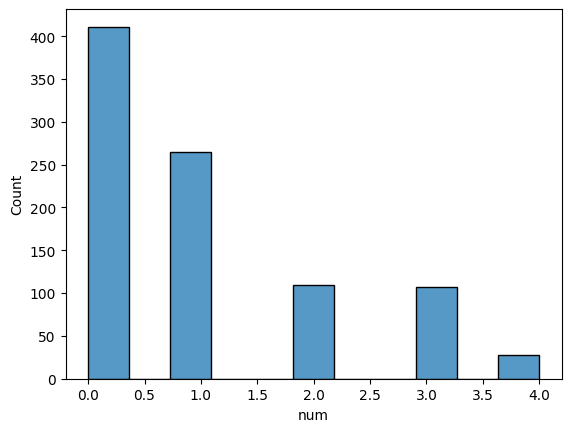

In [30]:
sns.histplot(data=df,x="num")
plt.show()

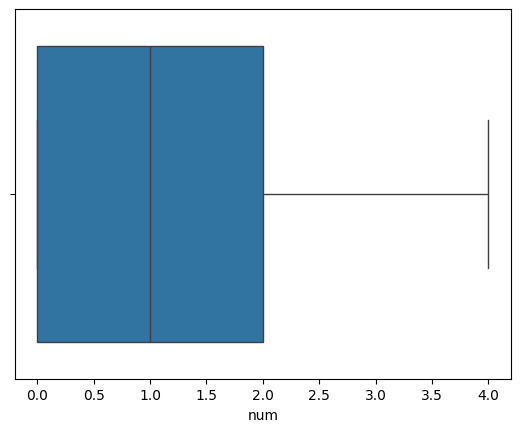

In [32]:
sns.boxplot(data=df,x="num")
plt.show()

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


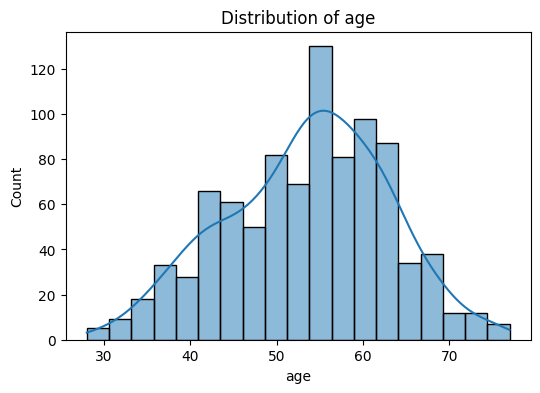

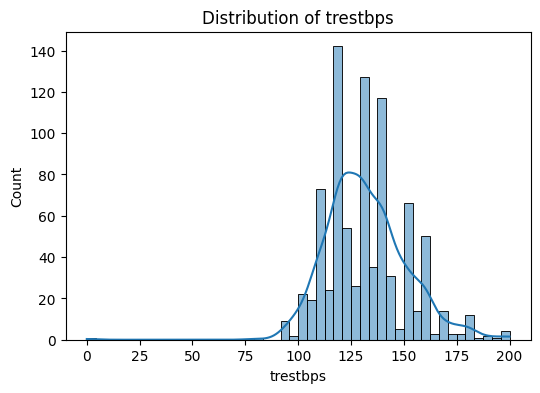

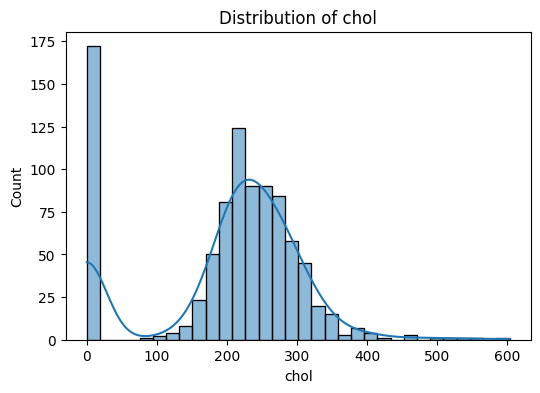

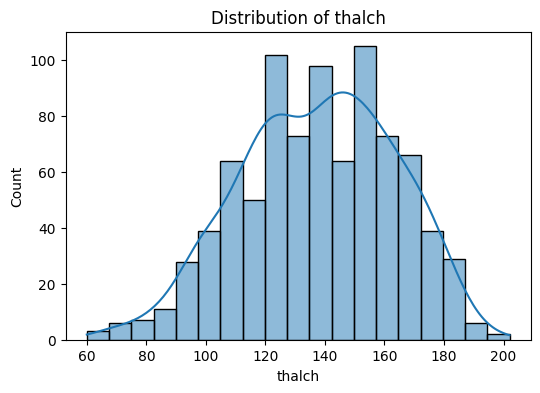

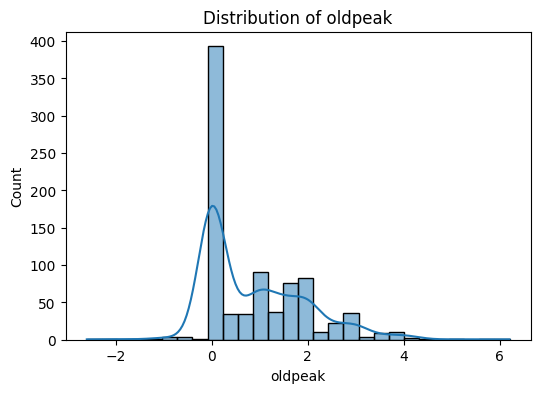

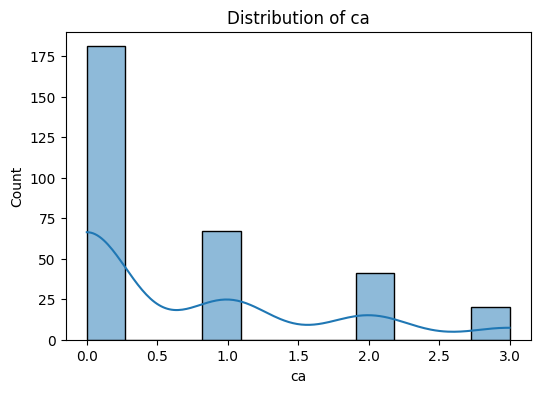

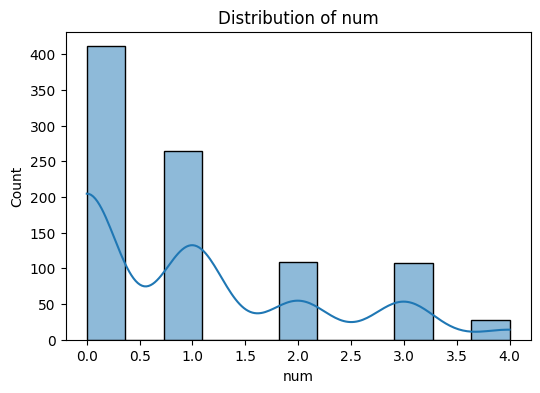

In [ ]:
x=["age","trestbps","chol","thalch","oldpeak","ca","num"]
for col in x:
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [38]:
for i in x:
    print(i)

age
trestbps
chol
thalch
oldpeak
ca
num


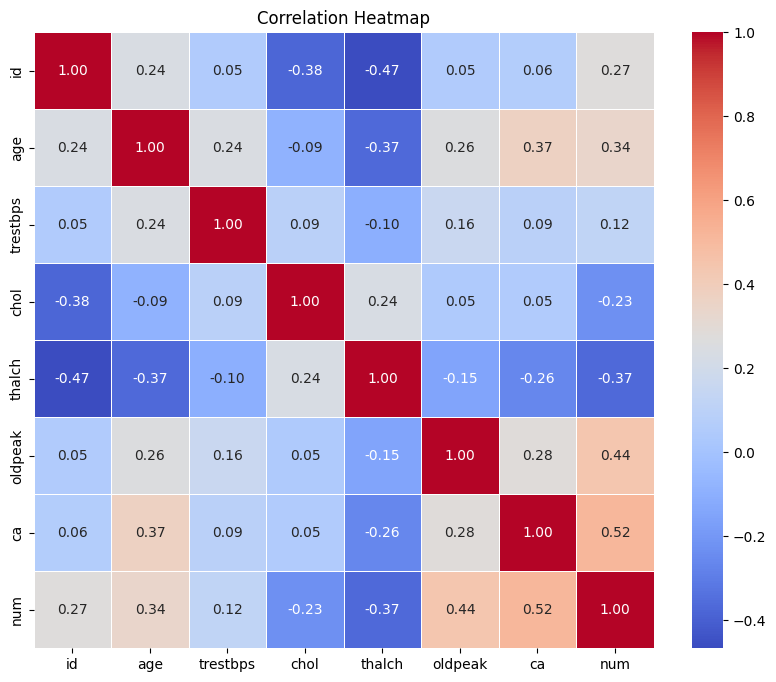

In [56]:
numeric_df = df.select_dtypes(include='number')

# Create correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [58]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

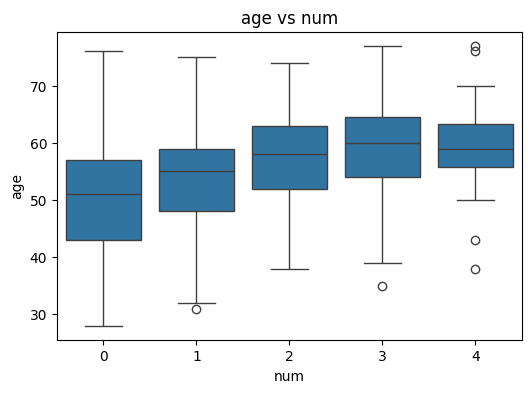

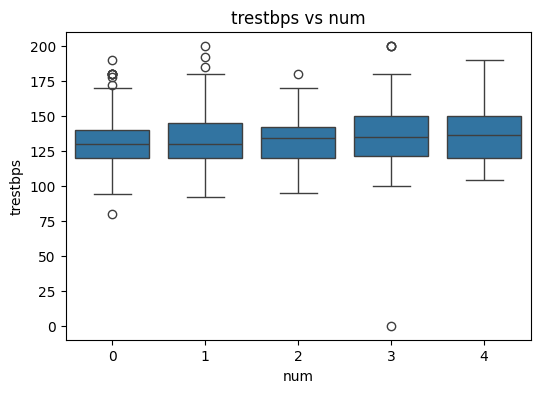

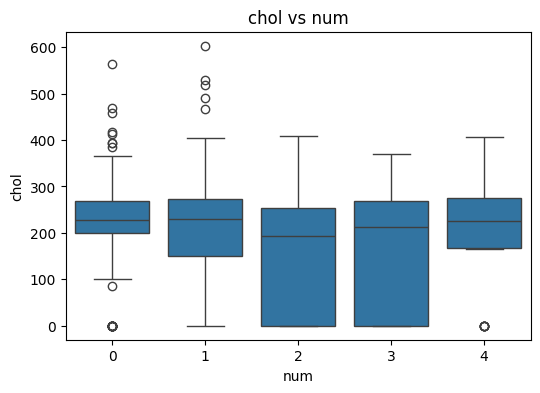

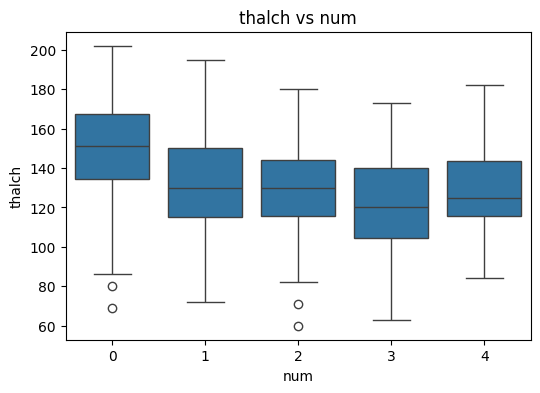

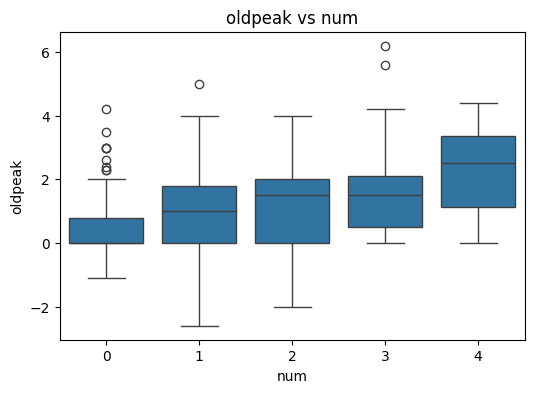

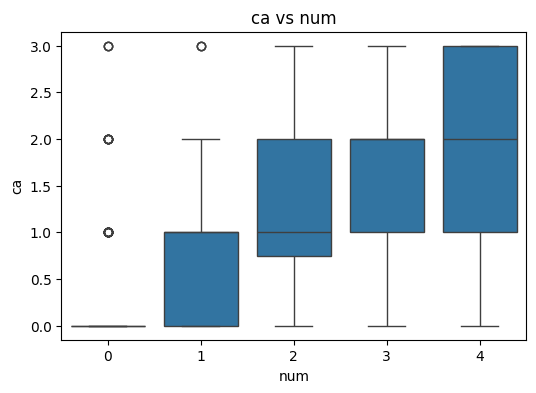

In [59]:
features = ["age","trestbps","chol","thalch","oldpeak","ca"]

for col in features:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df["num"], y=df[col])
    
    plt.title(f"{col} vs num")
    plt.show()

In [67]:
df=df.drop(columns="id")

In [87]:
df["slope"] = df["slope"].fillna(df["slope"].mode()[0])

In [88]:
df.isna().sum()

age          0
sex          0
dataset      0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
slope        0
num          0
dtype: int64

In [89]:
df.head(5)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [91]:
df.isna().sum()

age          0
sex          0
dataset      0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
slope        0
num          0
dtype: int64

In [97]:
# df[''].fillna(df['trestbps'].median(), inplace=True)
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].median())

In [98]:
df["trestbps"].isna().sum()

np.int64(0)

In [99]:
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'].fillna(df['chol'].median(), inplace=True)

C:\Users\pulki\AppData\Local\Temp\ipykernel_17476\3843958458.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['chol'].fillna(df['chol'].median(), inplace=True)


0      233.0
1      286.0
2      229.0
3      250.0
4      204.0
       ...  
915    333.0
916    139.0
917    223.0
918    385.0
919    254.0
Name: chol, Length: 920, dtype: float64

In [100]:
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'] = df['chol'].fillna(df['chol'].median())

TypeError: 'method' object is not subscriptable

In [104]:
df = df[df['trestbps'] >= 50]

In [105]:
df

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,flat,1
916,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,NaN,NaN,NaN,flat,0
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,flat,2
918,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,NaN,NaN,NaN,flat,0


In [106]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
print(df['num'].value_counts())

num
1    508
0    411
Name: count, dtype: int64


In [107]:
# continuous — median
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'] = df['chol'].fillna(df['chol'].median())

# categorical — mode
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

In [108]:
print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64


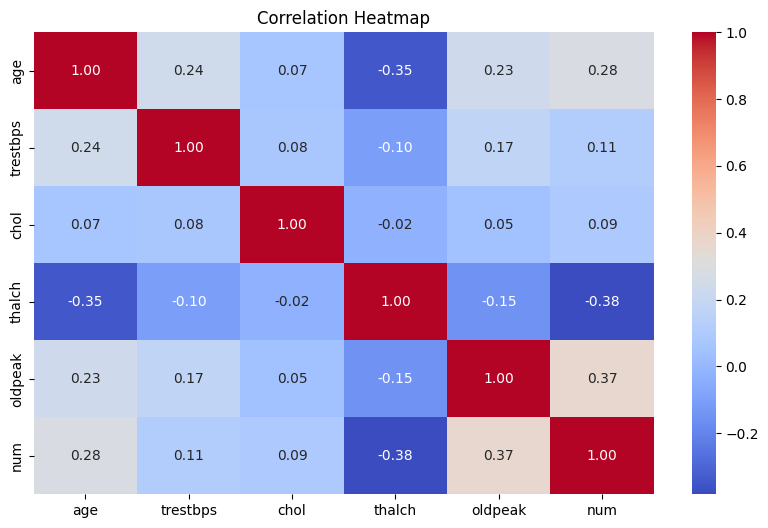

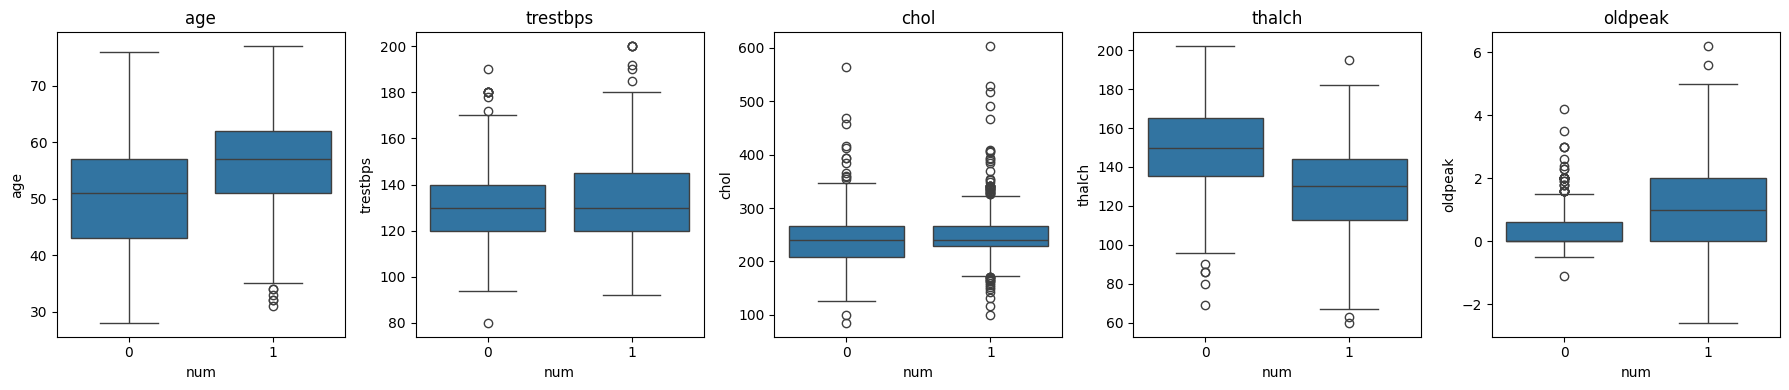

In [109]:
# correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# boxplots — num vs each numerical feature
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(x='num', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [110]:
df.to_csv('../data/processed/heart_cleaned.csv', index=False)

In [111]:
print(df.shape)
print(df.isnull().sum())
print(df['num'].value_counts())

(919, 13)
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64
num
1    508
0    411
Name: count, dtype: int64


In [113]:
df['fbs'] = df['fbs'].map({'True': True, 'False': False}).astype(bool)
df['exang'] = df['exang'].map({'True': True, 'False': False}).astype(bool)


In [114]:
df.to_csv('../data/processed/heart_cleaned.csv', index=False)
print("saved")

saved


In [116]:
print(df.select_dtypes(include='str').columns.tolist())
print(df.select_dtypes(include='bool').columns.tolist())

['sex', 'dataset', 'cp', 'restecg', 'slope']
['fbs', 'exang']
